## Sommaire
Navigation rapide vers les sections du notebook.

- [Partie 1 - Regression logistique multiclasse basique](#partie-1---regression-logistique-multiclasse-basique)
- [Partie 2 - Limitation de l eparpillement des classes](#partie-2---limitation-de-l-eparpillement-des-classes)
- [Partie 3 - Regression logistique avec balanced](#partie-3---regression-logistique-avec-balanced)
- [Partie 4 - Regression logistique avec CV en 5 folds](#partie-4---regression-logistique-avec-cv-en-5-folds)
- [Partie 5 - RN basique sans optimisation](#partie-5---rn-basique-sans-optimisation)

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier



In [2]:
df = pd.read_csv(r"c:\Users\AsgharAli Thomas\Documents\RFID2\DS.csv")
df.shape

(4411, 160)

On introduit les variables x, y, z. On fait via str split

In [3]:
if "xyz" in df.columns:
    xyz_split = df["xyz"].astype(str).str.split("__", expand=True)
    if xyz_split.shape[1] >= 3:
        df[["x", "y", "z"]] = xyz_split.iloc[:, :3]

required = ["x", "y", "z"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df: {missing}")

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.reset_index(drop=True)

print("Shape df:", df.shape)
df[["x", "y", "z"]].head()

Shape df: (4411, 160)


,x,y,z
0,1.82,2.51,0.05
1,10.10,3.82,1.29
2,10.34,3.33,0.05
3,10.51,3.26,0.05
4,10.71,3.92,1.57


On veut maintenant, crées des voxels de taille 1 en 3D. x-> i, y-> j, z-> k
ici les classes n'ont pas de sens, mais en baseline on peut tester pour voir les resultats que cela peut donner.


In [4]:
import numpy as np
import pandas as pd

h = 1  # taille du voxel

for c in ["x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z"]).copy()

df["i"] = np.floor(df["x"] / h).astype(int)
df["j"] = np.floor(df["y"] / h).astype(int)
df["k"] = np.floor(df["z"] / h).astype(int)

Nx = df["i"].max() + 1 # nombres de voxels en x, y, z
Ny = df["j"].max() + 1
Nk = df["k"].max() + 1

df["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]

X = df.drop(columns=[
    "i",
    "j",
    "k",
    "class_id",
    "x",
    "y",
    "z",
    "xyz"
], errors="ignore")

# Retirer toutes les colonnes non numeriques pour eviter l erreur du scaler
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors="ignore")


# Anti-fuite: ne garder que les vraies features RSSI
rssi_cols = [c for c in df.columns if c.startswith("max__Delta_rssi")]
if not rssi_cols:
    raise ValueError("Aucune colonne RSSI trouvee (prefixe max__Delta_rssi)")

X_small = df[rssi_cols].copy()

print("Nombre de classes :", target.nunique())
print("Nombre final de features RSSI :", X.shape[1])
print("Nombre de features RSSI selectionnees :", X_small.shape[1])

Nombre de classes : 74
Nombre final de features RSSI : 153
Nombre de features RSSI selectionnees : 24


In [5]:
df['class_id'].nunique()

74

Nombre de classes: 74
Min/Max par classe: 10 / 160
Ratio de disparite (max/min): 16.00
Coefficient de variation: 0.587


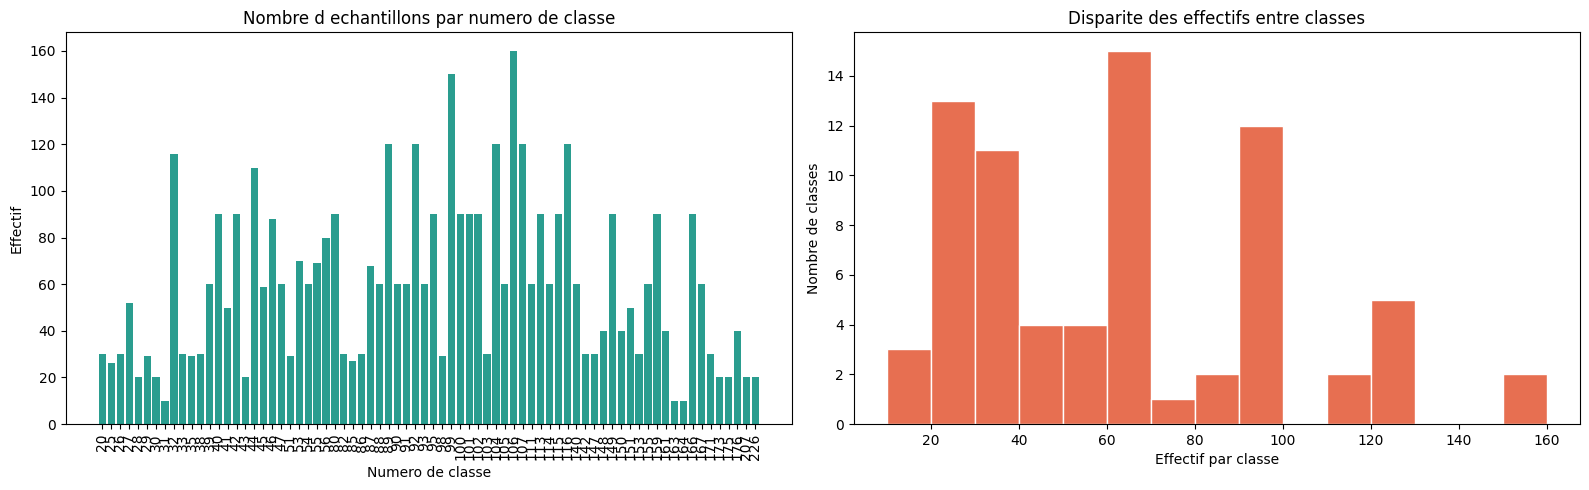

In [6]:
import matplotlib.pyplot as plt

class_counts = target.value_counts().sort_index()

min_count = int(class_counts.min())
max_count = int(class_counts.max())
mean_count = float(class_counts.mean())
std_count = float(class_counts.std(ddof=0))
imbalance_ratio = max_count / max(min_count, 1)
cv = std_count / mean_count if mean_count > 0 else np.nan

print(f"Nombre de classes: {class_counts.shape[0]}")
print(f"Min/Max par classe: {min_count} / {max_count}")
print(f"Ratio de disparite (max/min): {imbalance_ratio:.2f}")
print(f"Coefficient de variation: {cv:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(class_counts.index.astype(str), class_counts.values, color="#2a9d8f")
axes[0].set_title("Nombre d echantillons par numero de classe")
axes[0].set_xlabel("Numero de classe")
axes[0].set_ylabel("Effectif")
axes[0].tick_params(axis="x", labelrotation=90)

axes[1].hist(class_counts.values, bins=15, color="#e76f51", edgecolor="white")
axes[1].set_title("Disparite des effectifs entre classes")
axes[1].set_xlabel("Effectif par classe")
axes[1].set_ylabel("Nombre de classes")

plt.tight_layout()
plt.show()

Pour l'instant on fait une classif basique mais on pourrait aussi essayer en normalisant standars scaler ne regle pas le desiquilibre de classe. Donc deuxieme pîste d'amélioratino


In [7]:
# Verification: class_id est cree a partir de la position voxel (i, j, k)
check_cols = ["xyz","x", "y", "z", "i", "j", "k", "class_id"]
display(df[check_cols].head(10))

labels_uniques = np.sort(df["class_id"].unique())
print("Nombre de labels uniques:", len(labels_uniques))
print("Premiers labels tries:", labels_uniques[:10])



,xyz,x,y,z,i,j,k,class_id
0,1.82__2.51__0.05,1.82,2.51,0.05,1,2,0,25
1,10.1__3.82__1.29,10.10,3.82,1.29,10,3,1,106
2,10.34__3.33__0.05,10.34,3.33,0.05,10,3,0,46
3,10.51__3.26__0.05,10.51,3.26,0.05,10,3,0,46
4,10.71__3.92__1.57,10.71,3.92,1.57,10,3,1,106
5,10.72__3.5__0.05,10.72,3.50,0.05,10,3,0,46
6,10.79__3.89__1.57,10.79,3.89,1.57,10,3,1,106
7,10.98__1.98__1.1300000000000001,10.98,1.98,1.13,10,1,1,82
8,11.01__3.87__1.08,11.01,3.87,1.08,11,3,1,107
9,11.16__3.95__1.07,11.16,3.95,1.07,11,3,1,107


Nombre de labels uniques: 74
Premiers labels tries: [20 25 26 27 28 29 30 31 32 33]


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (3528, 153)
Test: (883, 153)


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# Anti-fuite: on separe par groupe de position xyz
groups = df.loc[X_small.index, "xyz"].astype(str) if "xyz" in df.columns else df.loc[X.index].index.astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_small, target, groups=groups))

X_train_small, X_test_small = X_small.iloc[train_idx], X_small.iloc[test_idx]
y_train_small, y_test_small = target.iloc[train_idx], target.iloc[test_idx]

print("Train:", X_train_small.shape)
print("Test:", X_test_small.shape)
print("Groupes train:", groups.iloc[train_idx].nunique())
print("Groupes test:", groups.iloc[test_idx].nunique())

Train: (3529, 24)
Test: (882, 24)
Groupes train: 355
Groupes test: 89


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 153
num_classes = 74


## Partie 1 - Regression logistique multiclasse basique
Modele baseline.

In [11]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_scaled, y_train)

y_pred = RLog.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.637599093997735


In [12]:
def decode_class_id(class_id, Nx, Ny):
    k = class_id // (Nx * Ny)
    remainder = class_id % (Nx * Ny)

    j = remainder // Nx
    i = remainder % Nx

    return i, j, k

In [13]:

def voxel_center(class_id, Nx, Ny, h):
    i, j, k = decode_class_id(class_id, Nx, Ny)

    x = (i + 0.5) * h
    y = (j + 0.5) * h
    z = (k + 0.5) * h

    return np.array([x, y, z])

In [14]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3 = []
xyz_test = []
for pred_id, true_xyz in zip(y_pred, true_coords):

    pred_xyz = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz)

    errors.append(err)
    predA3.append(pred_xyz)
    xyz_test.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.6349245013520493
Erreur mediane : 0.5591064299397746
Erreur max : 3.089741089476592


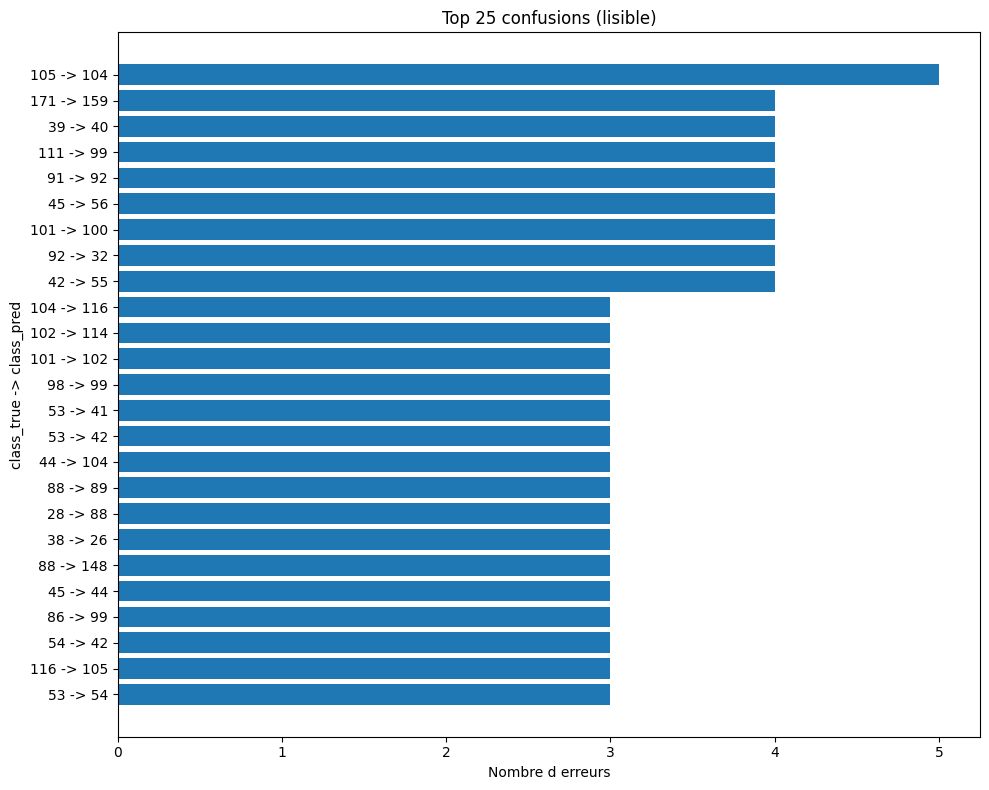

In [15]:
y_true = np.asarray(y_test).astype(int)
y_hat = np.asarray(y_pred).astype(int)

if y_true.shape[0] != y_hat.shape[0]:
    raise ValueError("y_test et y_pred n ont pas la meme taille.")

class_errors = pd.DataFrame({
    "class_true": y_true,
    "class_pred": y_hat,
})
class_errors = class_errors[class_errors["class_true"] != class_errors["class_pred"]].copy()

if class_errors.empty:
    print("Aucune erreur de class_id a afficher.")
else:
    confusion_err = (
        class_errors.groupby(["class_true", "class_pred"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # 1) Top confusions en barres horizontales (plus lisible)
    top_n = 25
    top_err = confusion_err.head(top_n).copy()
    top_err["pair"] = top_err["class_true"].astype(str) + " -> " + top_err["class_pred"].astype(str)
    top_err = top_err.sort_values("count", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_err["pair"], top_err["count"])
    plt.title(f"Top {top_n} confusions (lisible)")
    plt.xlabel("Nombre d erreurs")
    plt.ylabel("class_true -> class_pred")
    plt.tight_layout()
    plt.show()

In [16]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred).astype(int),
    xyz_test,
    predA3
):

    dx = float(xyz_pred[0] - xyz_true[0])
    dy = float(xyz_pred[1] - xyz_true[1])
    dz = float(xyz_pred[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))  # distance 3D

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),

        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),

        "x_pred": float(xyz_pred[0]),
        "y_pred": float(xyz_pred[1]),
        "z_pred": float(xyz_pred[2]),

        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff))

# erreurs > 1 m
df_diff_1m = df_diff[df_diff["distance"] > 1]

print("Nombre d'erreurs > 1 m:", len(df_diff_1m))

display(df_diff_1m.head(20))

print(df_diff_1m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d'erreurs > 1 m: 114


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
4,53,55,5.55,4.09,0.42,7.5,4.5,0.5,1.95,0.41,0.08,1.994242
12,151,91,7.86,2.99,2.40,7.5,2.5,1.5,-0.36,-0.49,-0.90,1.086140
15,53,54,5.55,4.09,0.42,6.5,4.5,0.5,0.95,0.41,0.08,1.037786
22,101,102,5.04,3.83,1.70,6.5,3.5,1.5,1.46,-0.33,-0.20,1.510132
24,176,105,8.47,4.52,2.35,9.5,3.5,1.5,1.03,-1.02,-0.85,1.680417
37,89,150,5.63,2.34,1.93,6.5,2.5,2.5,0.87,0.16,0.57,1.052331
53,149,89,5.67,2.44,2.54,5.5,2.5,1.5,-0.17,0.06,-1.04,1.055509
61,90,163,6.31,2.75,1.77,7.5,3.5,2.5,1.19,0.75,0.73,1.584771
63,150,89,6.34,2.69,2.07,5.5,2.5,1.5,-0.84,-0.19,-0.57,1.032763
76,41,29,5.68,3.49,0.37,5.5,2.5,0.5,-0.18,-0.99,0.13,1.014594


       class_id_true  class_id_pred          dx          dy          dz  \
count     114.000000     114.000000  114.000000  114.000000  114.000000   
mean       96.228070      96.596491    0.037368   -0.089649    0.135702   
std        41.889876      42.656421    0.871345    0.869890    0.563115   
min        20.000000      20.000000   -2.190000   -3.020000   -1.140000   
25%        53.000000      55.000000   -0.790000   -0.627500   -0.170000   
50%       101.000000     100.500000   -0.065000    0.010000    0.130000   
75%       115.000000     115.000000    0.915000    0.645000    0.477500   
max       207.000000     175.000000    1.950000    2.040000    1.660000   

         distance  
count  114.000000  
mean     1.314153  
std      0.344765  
min      1.001199  
25%      1.101351  
50%      1.193377  
75%      1.401641  
max      3.089741  


faudrait dig sur pq cette data donne ces erreurs maisjsp cmt faire 

On réessaie le même modèle mais cette fois ci avec X small


In [17]:
scaler = StandardScaler()

X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

num_features = X_train_small_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 24
num_classes = 74


In [18]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_small_scaled, y_train_small)

y_pred = RLog.predict(X_test_small_scaled)
acc_lr = accuracy_score(y_test_small, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.11791383219954649


aucun interet de continuer au vu de l'accuracy je pense.

## Partie 2 - Limitation de l eparpillement des classes
Reduction des classes surrepresentees; impact faible observe.

In [19]:
# Proportion de chaque class_id dans un DataFrame
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index()
    .sort_values("class_id")
    .reset_index(drop=True)
)

print("Nombre de classes:", df_prop_class.shape[0])

display(df_prop_class.max())
mean = df_prop_class["class_id"].mean()
print("Moyenne:", mean)


Nombre de classes: 74


class_id    226
count       160
dtype: int64

Moyenne: 96.01351351351352


In [20]:
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index(name="count")
)

print("Nombre de classes:", df_prop_class.shape[0])

# afficher les classes les plus représentées
display(df_prop_class.sort_values("count", ascending=True).head(20))

Nombre de classes: 74


,class_id,count
72,163,10
73,164,10
71,31,10
65,43,20
64,30,20
66,173,20
68,207,20
67,28,20
69,226,20
70,175,20


## Partie 3 - Regression logistique avec balanced
Test avec class_weight="balanced" pour compenser le desequilibre.

In [21]:
from sklearn.linear_model import LogisticRegression

RLog_balenced = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

RLog_balenced.fit(X_train_scaled, y_train)

y_pred_balenced = RLog_balenced.predict(X_test_scaled)
acc_lr_balenced = accuracy_score(y_test, y_pred_balenced)

print("Logistic Regression accuracy:", acc_lr_balenced)

Logistic Regression accuracy: 0.6138165345413363


etonnament l'accuracy descends ... néanmoins ce n'est pas une metrics fiable on va tester d'avantage.


In [82]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_balenced = []
xyz_test_balenced = []
for pred_id, true_xyz in zip(y_pred_balenced, true_coords):

    pred_xyz_balenced = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz_balenced)

    errors.append(err)
    predA3_balenced.append(pred_xyz_balenced)
    xyz_test_balenced.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.6782297965798247
Erreur mediane : 0.5707013229352109
Erreur max : 5.159515481128048


In [83]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred_balenced in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_balenced).astype(int),
    xyz_test_balenced,
    predA3_balenced
):
    dx = float(xyz_pred_balenced[0] - xyz_true[0])
    dy = float(xyz_pred_balenced[1] - xyz_true[1])
    dz = float(xyz_pred_balenced[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_balenced[0]),
        "y_pred": float(xyz_pred_balenced[1]),
        "z_pred": float(xyz_pred_balenced[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_balenced = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_balenced))

df_diff_balenced_1p7m = df_diff_balenced[df_diff_balenced["distance"] > 3]
print("Nombre d erreurs > 1.7 m:", len(df_diff_balenced_1p7m))

display(df_diff_balenced_1p7m.head(20))

print(df_diff_balenced_1p7m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 3


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
440,116,20,8.56,4.52,1.15,8.5,1.5,0.5,-0.06,-3.02,-0.65,3.089741
449,116,80,8.56,4.52,1.15,8.5,1.5,1.5,-0.06,-3.02,0.35,3.040806
600,55,26,7.39,4.12,0.79,2.5,2.5,0.5,-4.89,-1.62,-0.29,5.159515


       class_id_true  class_id_pred        dx        dy        dz  distance
count       3.000000       3.000000  3.000000  3.000000  3.000000  3.000000
mean       95.666667      42.000000 -1.670000 -2.553333 -0.196667  3.763354
std        35.218366      33.045423  2.788602  0.808290  0.506491  1.209359
min        55.000000      20.000000 -4.890000 -3.020000 -0.650000  3.040806
25%        85.500000      23.000000 -2.475000 -3.020000 -0.470000  3.065273
50%       116.000000      26.000000 -0.060000 -3.020000 -0.290000  3.089741
75%       116.000000      53.000000 -0.060000 -2.320000  0.030000  4.124628
max       116.000000      80.000000 -0.060000 -1.620000  0.350000  5.159515


on observe pas des résultat proprement meilleurs, néanmoins on peut également tester d'autre méthode.

## Partie 4 - Regression logistique avec CV en 5 folds
Evaluation par validation croisee (5 folds).

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

RLog_cv = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=53
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RLog_cv, X_train, y_train, cv=cv)

print("CV accuracy scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())

# entrainement final
RLog_cv.fit(X_train, y_train)

y_pred_cv = RLog_cv.predict(X_test)
acc_lr_cv = accuracy_score(y_test, y_pred_cv)

print("Test accuracy:", acc_lr_cv)

CV accuracy scores: [0.80736544 0.80878187 0.80453258 0.8212766  0.81702128]
CV mean accuracy: 0.8117955518051956
Test accuracy: 0.8369195922989807


In [128]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_cv = []
xyz_test_cv = []
for pred_id, true_xyz in zip(y_pred_cv, true_coords):

    pred_xyz_cv = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz_cv)

    errors.append(err)
    predA3_cv.append(pred_xyz_cv)
    xyz_test_cv.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.5056027141087178
Erreur mediane : 0.49658836071740525
Erreur max : 3.089741089476592


lerreur max descend de 5 a 3 ? positif :)


In [172]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred_cv in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv).astype(int),
    xyz_test_cv,
    predA3_cv
):
    dx = float(xyz_pred_cv[0] - xyz_true[0])
    dy = float(xyz_pred_cv[1] - xyz_true[1])
    dz = float(xyz_pred_cv[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv[0]),
        "y_pred": float(xyz_pred_cv[1]),
        "z_pred": float(xyz_pred_cv[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv))

df_diff_cv_1p3m = df_diff_cv[df_diff_cv["distance"] > 1.3]
print("Nombre d erreurs > 1.3 m:", len(df_diff_cv_1p3m))

display(df_diff_cv_1p3m.head(20))

print(df_diff_cv_1p3m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 2


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
440,116,20,8.56,4.52,1.15,8.5,1.5,0.5,-0.06,-3.02,-0.65,3.089741
449,116,176,8.56,4.52,1.15,8.5,4.5,2.5,-0.06,-0.02,1.35,1.351481


       class_id_true  class_id_pred    dx       dy        dz  distance
count            2.0       2.000000  2.00  2.00000  2.000000  2.000000
mean           116.0      98.000000 -0.06 -1.52000  0.350000  2.220611
std              0.0     110.308658  0.00  2.12132  1.414214  1.229136
min            116.0      20.000000 -0.06 -3.02000 -0.650000  1.351481
25%            116.0      59.000000 -0.06 -2.27000 -0.150000  1.786046
50%            116.0      98.000000 -0.06 -1.52000  0.350000  2.220611
75%            116.0     137.000000 -0.06 -0.77000  0.850000  2.655176
max            116.0     176.000000 -0.06 -0.02000  1.350000  3.089741


In [34]:
df.columns

Index(['EPC', 'xyz', 'max__Delta_rssi__24.0__041A9F60__NONE',
       'max__Delta_rssi__24.0__041A9F61__NONE',
       'max__Delta_rssi__24.0__0F173B12__NONE',
       'max__Delta_rssi__24.0__0F173B13__NONE',
       'max__Delta_rssi__24.0__PORT_1__NONE',
       'max__Delta_rssi__24.0__PORT_2__NONE',
       'max__Delta_rssi__24.0__PORT_3__NONE',
       'max__Delta_rssi__24.0__PORT_4__NONE',
       ...
       'D_PORT_1', 'D_PORT_2', 'D_PORT_3', 'D_PORT_4', 'nearestAnt',
       'D_nearestAnt', 'i', 'j', 'k', 'class_id'],
      dtype='object', length=164)

### Moyenne des probabilités pour améliorer la localisation

Actuellement, le modèle prédit un **voxel** via une régression logistique multinomiale.  
La position \((x,y,z)\) est ensuite obtenue en prenant **le centre du voxel le plus probable (argmax)**.

Cependant, l’argmax utilise uniquement la classe la plus probable et **ignore l’information contenue dans le reste de la distribution de probabilités**.

L’idée est donc d’utiliser les probabilités prédites pour calculer **une moyenne pondérée des centres des voxels** :

$$
(\hat{x}, \hat{y}, \hat{z}) = \sum_{k} p_k \,(x_k, y_k, z_k)
$$

où :

- $p_k$ est la probabilité prédite pour le voxel $k$
- $(x_k, y_k, z_k)$ est le centre du voxel $k$

Cette approche permet de **réduire l’erreur de discrétisation liée aux voxels**.  
Si le modèle hésite entre plusieurs voxels voisins, la moyenne pondérée permet de prédire une position **intermédiaire**, souvent plus proche de la position réelle que celle obtenue avec l’argmax.

In [131]:
RLog_cv_mean = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=53
)

folds = KFold(n_splits=8, shuffle=True, random_state=42)
cv_scores_mean = cross_val_score(RLog_cv, X_train_scaled, y_train, cv=folds)

print("CV accuracy scores:", cv_scores_mean)
print("CV mean accuracy:", cv_scores_mean.mean())

# entraînement final
RLog_cv_mean.fit(X_train_scaled, y_train)

distrib_proba = RLog_cv_mean.predict_proba(X_test_scaled)




CV accuracy scores: [0.57369615 0.57823129 0.56462585 0.59863946 0.60770975 0.58276644
 0.57369615 0.58276644]
CV mean accuracy: 0.5827664399092971


In [132]:
classes = RLog_cv_mean.classes_.astype(float)   # ex: [0, 1, 2, ...] ou labels réels
classes.shape

(74,)

In [133]:
distrib_proba[1].shape

(74,)

In [134]:
y_pred_cv_mean = []
n = len(distrib_proba)

for i in range(n):
    a = np.sum(distrib_proba[i] * classes)
    y_pred_cv_mean.append(a)

centers = np.array([voxel_center(int(c), Nx, Ny, h) for c in classes], dtype=float) # on construit la table des centres de chaques voxels
predA3_cv_mean = distrib_proba @ centers # on fait le produit matriciel entre les proba et les centres pour obtenir la position prédite en continu (non discrète)


predA3_cv_mean.shape


(883, 3)

In [135]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy(dtype=float)


errors = np.linalg.norm(true_coords - predA3_cv_mean, axis=1)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.45064305763686924
Erreur mediane : 0.41775065870929945
Erreur max : 3.08609858895071


In [ ]:
rows_diff = []

for class_true, class_pred_mean, xyz_true, xyz_pred_cv_mean in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv_mean, dtype=float),
    xyz_test_cv_mean,
    predA3_cv_mean
):
    dx = float(xyz_pred_cv_mean[0] - xyz_true[0])
    dy = float(xyz_pred_cv_mean[1] - xyz_true[1])
    dz = float(xyz_pred_cv_mean[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred_mean": float(class_pred_mean),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv_mean[0]),
        "y_pred": float(xyz_pred_cv_mean[1]),
        "z_pred": float(xyz_pred_cv_mean[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv_mean = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv_mean))

df_diff_cv_mean_1m = df_diff_cv_mean[df_diff_cv_mean["distance"] > 1]
print("Nombre d erreurs > 1 m:", len(df_diff_cv_mean_1m))

display(df_diff_cv_mean_1m.head(20))

print(df_diff_cv_mean_1m[[
    "class_id_true",
    "class_id_pred_mean",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1 m: 31


,class_id_true,class_id_pred_mean,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
22,101,127.838568,5.04,3.83,1.70,6.014092,3.531049,1.932532,0.974092,-0.298951,0.232532,1.045131
24,176,105.722142,8.47,4.52,2.35,9.363355,3.565729,1.501167,0.893355,-0.954271,-0.848833,1.558600
61,90,158.907849,6.31,2.75,1.77,7.051548,3.482434,2.442785,0.741548,0.732434,0.672785,1.240561
130,105,105.202361,9.30,3.70,1.02,10.462421,3.502223,1.486888,1.162421,-0.197777,0.466888,1.268197
131,149,89.011652,5.63,2.34,2.57,5.500000,2.500000,1.500194,-0.130000,0.160000,-1.069806,1.089488
170,166,106.128463,10.10,3.82,2.58,10.488343,3.499633,1.502409,0.388343,-0.320367,-1.077591,1.189390
177,207,162.928335,3.61,2.39,3.21,3.522179,3.395256,2.586051,-0.087821,1.005256,-0.623949,1.186408
194,41,41.651996,5.68,3.49,0.05,4.619117,3.516150,0.522318,-1.060883,0.026150,0.472318,1.161568
208,115,104.507549,7.73,4.45,1.67,7.663622,3.419035,1.538592,-0.066378,-1.030965,-0.131408,1.041423
242,54,110.229030,6.16,4.08,0.05,5.411049,4.409635,1.473373,-0.748951,0.329635,1.423373,1.641821


       class_id_true  class_id_pred_mean         dx         dy         dz  \
count      31.000000           31.000000  31.000000  31.000000  31.000000   
mean       99.032258          100.648623   0.032063  -0.199450   0.213747   
std        47.046420           40.579489   0.690421   0.877226   0.695036   
min        20.000000           20.122918  -1.147470  -3.016566  -1.077591   
25%        55.000000           60.838151  -0.411845  -0.721332  -0.260612   
50%       101.000000          106.128463  -0.066378  -0.197777   0.415703   
75%       116.000000          125.886335   0.581540   0.274309   0.739798   
max       207.000000          162.928335   1.162421   1.550020   1.423373   

        distance  
count  31.000000  
mean    1.272319  
std     0.381975  
min     1.004738  
25%     1.085149  
50%     1.182225  
75%     1.261869  
max     3.086099  


In [186]:
# Comparaison ciblee: classe vraie, classes predites et distances (CV vs CV moyenne ponderee)
n = min(len(df_diff_cv), len(df_diff_cv_mean))
if n == 0:
    raise ValueError("df_diff_cv ou df_diff_cv_mean est vide, relance les cellules CV avant comparaison")

left = df_diff_cv[["class_id_true", "class_id_pred", "distance"]].iloc[:n].reset_index(drop=True)
right = df_diff_cv_mean[["class_id_true", "class_id_pred_mean", "distance"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_cv": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(float),
    "distance_cv": left["distance"].astype(float),
    "distance_cv_mean": right["distance"].astype(float),
})

comp["delta_class_id_pred"] = comp["class_id_pred_cv"] - comp["class_id_pred_cv_mean"]
comp["delta_distance"] = comp["distance_cv"] - comp["distance_cv_mean"]

# Garder uniquement les lignes differentes entre les deux approches
tol = 1e-12
mask_diff = (
    (comp["delta_class_id_pred"].abs() > tol)
    | (comp["delta_distance"].abs() > tol)
)

df_comp = comp.loc[mask_diff].reset_index(drop=True)

print("Lignes comparees:", len(comp))
print("Lignes differentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance"]].describe())

Lignes comparees: 883
Lignes differentes: 883


,class_id_true,class_id_pred_cv,class_id_pred_cv_mean,distance_cv,distance_cv_mean,delta_class_id_pred,delta_distance
0,91,92,74.009186,0.899833,0.579926,17.990814,0.319908
1,105,104,112.145341,0.841962,0.465269,-8.145341,0.376693
2,95,95,94.947832,0.367287,0.370422,0.052168,-0.003135
3,100,100,100.850531,0.234307,0.435597,-0.850531,-0.201290
4,53,53,51.583875,0.420714,0.818898,1.416125,-0.398185
5,27,27,41.270250,0.477179,0.545877,-14.270250,-0.068698
6,149,89,117.397271,0.742226,0.305569,-28.397271,0.436657
7,101,100,93.605673,0.776531,0.484683,6.394327,0.291848
8,93,93,121.445809,0.510490,0.560181,-28.445809,-0.049691
9,114,114,113.994880,0.602080,0.573039,0.005120,0.029041


       delta_class_id_pred  delta_distance
count           883.000000      883.000000
mean              0.712863        0.054960
std              16.852705        0.262516
min             -79.927492       -0.929251
25%              -5.731291       -0.045679
50%              -0.270077        0.053200
75%               6.930112        0.204594
max              68.274695        1.001785


## Partie 5 - RN basique sans optimisation
Reseau de neurones de base, sans tuning avance.

In [29]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    batch_size=64,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

model.fit(X_train_scaled, y_train)

test_acc = model.score(X_test_scaled, y_test)

print("Test accuracy:", test_acc)

Test accuracy: 0.8187995469988675


In [30]:
proba = model.predict_proba(X_test_scaled)

y_pred_RN = model.predict(X_test_scaled)

y_true = y_test.to_numpy()

acc = accuracy_score(y_true, y_pred_RN)

print("Accuracy class_id:", acc)

Accuracy class_id: 0.8187995469988675


In [31]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_RN = []
xyz_test_RN = []
for pred_id, true_xyz in zip(y_pred_RN, true_coords):

    pred_xyz_RN = voxel_center(pred_id, Nx, Ny, h)
    err = np.linalg.norm(true_xyz - pred_xyz_RN)

    errors.append(err)
    predA3_RN.append(y_pred_RN)
    xyz_test_RN.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.5283137552934711
Erreur mediane : 0.5069516742254631
Erreur max : 3.466136177359453


In [32]:
import numpy as np
import pandas as pd

true_ids = np.asarray(y_test).astype(int)
pred_ids = np.asarray(y_pred_cv).astype(int)

# Rebuild arrays as proper NumPy 2D arrays (avoid list[:, 0] TypeError)
true_ids = np.asarray(y_test).astype(int)
pred_ids = np.asarray(y_pred_RN).astype(int)  # keep class_id_pred aligned with predA3_mean

xyz_test_RN = df.loc[y_test.index, ["x", "y", "z"]].to_numpy(dtype=float)
predA3_RN = np.array([voxel_center(int(cid), Nx, Ny, h) for cid in pred_ids], dtype=float)

if predA3_RN.shape != xyz_test_RN.shape:
    raise ValueError(f"Shape mismatch: predA3_RN={predA3_RN.shape}, xyz_test_RN={xyz_test_RN.shape}")

dx = predA3_RN[:, 0] - xyz_test_RN[:, 0]
dy = predA3_RN[:,1] - xyz_test_RN[:,1]
dz = predA3_RN[:,2] - xyz_test_RN[:,2]

dist = np.linalg.norm(predA3_RN - xyz_test_RN, axis=1)

df_diff_mean = pd.DataFrame({
    "class_id_true": true_ids,
    "class_id_pred": pred_ids,
    "x_true": xyz_test_RN[:,0],
    "y_true": xyz_test_RN[:,1],
    "z_true": xyz_test_RN[:,2],
    "x_pred": predA3_RN[:,0],
    "y_pred": predA3_RN[:,1],
    "z_pred": predA3_RN[:,2],
    "dx": dx,
    "dy": dy,
    "dz": dz,
    "distance": dist
})

print("Nombre total de lignes:", len(df_diff_mean))

df_diff_mean_1p7m = df_diff_mean[df_diff_mean["distance"] > 1.3]

print("Nombre d erreurs > 2 m:", len(df_diff_mean_1p7m))

display(df_diff_mean_1p7m.head(20))

print(df_diff_mean_1p7m[
    ["class_id_true","class_id_pred","dx","dy","dz","distance"]
].describe())

Nombre total de lignes: 883
Nombre d erreurs > 2 m: 11


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
24,176,104,8.47,4.52,2.35,8.5,3.5,1.5,0.03,-1.02,-0.85,1.328081
121,102,30,6.16,3.97,1.02,6.5,2.5,0.5,0.34,-1.47,-0.52,1.595901
242,54,114,6.16,4.08,0.05,6.5,4.5,1.5,0.34,0.42,1.45,1.547417
353,45,106,9.30,3.70,0.70,10.5,3.5,1.5,1.20,-0.20,0.80,1.456022
371,102,161,6.16,3.97,1.34,5.5,3.5,2.5,-0.66,-0.47,1.16,1.414956
461,41,54,5.68,3.49,0.05,6.5,4.5,0.5,0.82,1.01,0.45,1.376590
636,56,45,8.87,4.79,0.37,9.5,3.5,0.5,0.63,-1.29,0.13,1.441492
668,41,100,5.69,3.07,0.74,4.5,3.5,1.5,-1.19,0.43,0.76,1.476008
731,173,92,5.50,4.15,2.04,8.5,2.5,1.5,3.00,-1.65,-0.54,3.466136
811,176,140,8.56,4.52,2.12,8.5,1.5,2.5,-0.06,-3.02,0.38,3.044405


       class_id_true  class_id_pred         dx         dy         dz  \
count      11.000000      11.000000  11.000000  11.000000  11.000000   
mean      101.727273      96.545455   0.307273  -0.497273   0.220909   
std        58.055303      39.747613   1.170599   1.372393   0.800081   
min        41.000000      30.000000  -1.190000  -3.020000  -0.850000   
25%        49.500000      73.000000  -0.360000  -1.380000  -0.530000   
50%       102.000000     104.000000   0.340000  -0.470000   0.380000   
75%       163.000000     115.000000   0.725000   0.425000   0.780000   
max       176.000000     161.000000   3.000000   1.790000   1.450000   

        distance  
count  11.000000  
mean    1.852459  
std     0.740725  
min     1.328081  
25%     1.428224  
50%     1.476008  
75%     1.912973  
max     3.466136  


tester via optuna

### Decision Tree :
Je pense qu'il peut être judicieux de vraiment tester les arbres de décision. dans un premier temps on a vu que Extra Treefonctionnait donc c une voix encouragente  et je pense que pour comprendre mieux comme les datas sont séparés faire ce type d'algo est bénéfique pour mieux comprendre et intérpreter les erreurs